# Assessing Bicycle Lane Quality Using Smartphone Sensor Data

This notebook contains the complete data analysis pipeline for
classifying bicycle-lane sections as Smooth or Bumpy using
smartphone sensor data.

The analysis includes data loading, preprocessing, feature
extraction, feature selection, supervised and unsupervised
learning, model evaluation, and deployment.

> **Group members:**
>
> | Name | Student number |
> |---|---|
> | Himanshu Khartade | 2431459 |
> | Aniket Zade | 2431491 |
> | Yuhan Shao | 2034964 |
>
> Participants are referred to as **P1, P2, P3** everywhere else (data files, plots, text) to keep the data anonymous.

# Environment and Reproducibility
The Python environment and package versions are recorded below to
support reproducibility.

In [1]:
import sys

import pandas as pd
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
import seaborn as sns

print("Python version:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas: 2.2.3
numpy: 2.3.5
scikit-learn: 1.9.0
matplotlib: 3.10.0


Terminologies:-

| Term | Meaning |
|---|---|
| **Accelerometer** | Sensor that measures how fast the phone's speed changes, along 3 directions (x, y, z), in m/s². Bumps make it jump. |
| **Gyroscope** | Sensor that measures how fast the phone rotates (tilts or turns), in rad/s. |
| **Gravity sensor** | The part of the motion caused by gravity, about 9.81 m/s² in total, stored in its own file. |
| **Magnitude** | One number combining x, y, z: the square root of x² + y² + z². It does not depend on how the phone is turned. |
| **Sampling rate (Hz)** | Readings per second. Here about 100. |
| **Window** | A short slice of a ride (here 2 seconds = 200 readings). Each window becomes one example for the models. |
| **Feature** | One number that summarises a window (for example its mean or standard deviation). |
| **Label** | The correct answer for an example: *smooth* or *bumpy*. |
| **Standard deviation (std)** | How much the values wobble around their average. A shakier signal has a larger std. |
| **RMS** | Root mean square, an average that gives extra weight to large values. |
| **Scaling (standardisation)** | Rewriting every feature so it has average 0 and std 1, so that no feature dominates just because its units are larger. |
| **PCA** | A way to replace many overlapping features by fewer new ones (components) that keep most of the information. |
| **Train / test split** | Most of the data (here 70 to 75 %) is used to learn and the rest (25 to 30 %) is to test the result. |
| **Supervised learning** | The model learns from examples that come with labels. |
| **Unsupervised learning** | The model is not given labels. It looks for natural groups (clusters). |
| **Confusion matrix** | A 2 × 2 table of right and wrong answers. Rows = real class, columns = predicted class. |
| **Accuracy** | Share of all windows classified correctly. |
| **Recall (bumpy)** | Of all really bumpy windows, the share the model found. |
| **Precision (bumpy)** | Of all windows the model called bumpy, the share that really were. |
| **F1 score** | One number balancing precision and recall. |
| **Cluster** | A group of similar windows found by an unsupervised method. |
| **ARI** | Adjusted Rand Index: agreement between clusters and the true labels. 0 ≈ pure chance, 1 = perfect. |
| **NMI** | Normalised Mutual Information: how much knowing the cluster tells you about the label. 0 = nothing, 1 = everything. |
| **Silhouette** | How tight and well separated the clusters are (−1 to 1). 

# Study Design & Data Collection

**Aim** Build a tool that classifies bike-lane surface quality — *smooth* or *bumpy* — from the motion sensors of a
smartphone.

**Participants** 3 group members (P1-P3), all course participants who can bike and have no condition that prevents
cycling. Every participant recorded one smooth and one bumpy ride.

**Sensors & settings** Sensor Logger app; accelerometer, gyroscope and gravity sensor only (all other sensors
off); default 100 Hz; *Standardisation* option on so iOS and Android exports are comparable.

**Procedure** Start recording → put the phone on the basket → ride the lane continuously → stop → take
the phone out → stop recording. Lane choice followed the protocol: *smooth* = a typical red cycling lane without imperfections;
*bumpy* = a commonly used lane with noticeable but not dangerous imperfections (small potholes, cracks, uneven surface).

**Data management**
- `data/Bumpy or data/Smooth` — untouched exports, one folder per participant and condition, consistent names, anonymized (P1-P3).
- `data/external_data/` — external datset for deployment and model evaluation

Each ride was saved as three separate files (`Accelerometer.csv`, `Gravity.csv`, `Gyroscope.csv`). The next three code cells turn them into one table per ride.

**load_and_merge()** reads the three files and renames the columns (`x, y, z` → `acc_x, acc_y, acc_z`, `grav_x…`, `gyro_x…`) so they do not clash. It also validates that the files have the same number of rows and identical timestamps, and stops with an error. Finally it puts everything side by side in one table.

In [2]:
def load_and_merge(acc_path, grav_path, gyro_path):
    """
    Load accelerometer, gravity, and gyroscope data and combine
    them using their timestamps.
    """

    acc = pd.read_csv(acc_path).rename(
        columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'}
    )

    grav = pd.read_csv(grav_path).rename(
        columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'}
    )

    gyro = pd.read_csv(gyro_path).rename(
        columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'}
    )

    # Check that all recordings have the same number of observations
    if not (len(acc) == len(grav) == len(gyro)):
        raise ValueError("Sensor files have different numbers of rows.")

    # Check timestamp alignment
    if not acc['time'].equals(grav['time']):
        raise ValueError("Accelerometer and gravity timestamps are not aligned.")

    if not acc['time'].equals(gyro['time']):
        raise ValueError("Accelerometer and gyroscope timestamps are not aligned.")

    # Combine the sensor measurements
    df = acc[
        ['time', 'seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']
    ].copy()

    df[['grav_x', 'grav_y', 'grav_z']] = grav[
        ['grav_x', 'grav_y', 'grav_z']
    ]

    df[['gyro_x', 'gyro_y', 'gyro_z']] = gyro[
        ['gyro_x', 'gyro_y', 'gyro_z']
    ]

    return df


**How the data is organised**

| Recording | Rider | Lane type (label) | Folder | Ride Location |
|---|---|---|---|---|
| P1_smooth | P1 | smooth | `data/Smooth/P1` | Near Geldropsedijk bus stop |
| P1_bumpy | P1 | bumpy | `data/Bumpy/P1` | Eisenhowerlaan |
| P2_smooth | P2 | smooth | `data/Smooth/P2` | Near Geldropsedijk bus stop |
| P2_bumpy | P2 | bumpy | `data/Bumpy/P2` | Opwettenseweg |
| P3_smooth | P3 | smooth | `data/Smooth/P3` | Circular bicycle path in TU/e |
| P3_bumpy | P3 | bumpy | `data/Bumpy/P3` | Brick-paved path near Luna, TU/e  |

**recordings** is a dictionary listing the six rides, each with its label and folder.

In [3]:
# Define the location of each participant's recordings

recordings = {
    'P1_smooth': {
        'label': 'smooth',
        'folder': 'data/Smooth/P1'
    },
    'P1_bumpy': {
        'label': 'bumpy',
        'folder': 'data/Bumpy/P1'
    },
    'P2_smooth': {
        'label': 'smooth',
        'folder': 'data/Smooth/P2'
    },
    'P2_bumpy': {
        'label': 'bumpy',
        'folder': 'data/Bumpy/P2'
    },
    'P3_smooth': {
        'label': 'smooth',
        'folder': 'data/Smooth/P3'
    },
    'P3_bumpy': {
        'label': 'bumpy',
        'folder': 'data/Bumpy/P3'
    }
}

In [4]:
# Dictionary to store the merged data for each recording
merge_recordings = {}

print("-----Number of samples and recording")
for name, recording in recordings.items():

    folder = recording['folder']

# Load and merge accelerometer, gravity, and gyroscope data
    df = load_and_merge(
        f"{folder}/Accelerometer.csv",
        f"{folder}/Gravity.csv",
        f"{folder}/Gyroscope.csv")

# Store the merged data using the recording name
    merge_recordings[name] = df
    
# Display the number of samples and recording duration
    print(
        f"{name}: "
        f"{len(df)} rows, "
        f"{df['seconds_elapsed'].max():.1f} seconds"
    )

-----Number of samples and recording
P1_smooth: 33176 rows, 332.2 seconds
P1_bumpy: 50749 rows, 508.1 seconds
P2_smooth: 49779 rows, 501.8 seconds
P2_bumpy: 50613 rows, 510.2 seconds
P3_smooth: 55894 rows, 561.1 seconds
P3_bumpy: 57708 rows, 579.3 seconds


| Recording | Rows | Seconds |
|---|---:|---:|
| P1_smooth | 33,176 | 332.2 |
| P1_bumpy | 50,749 | 508.1 |
| P2_smooth | 49,779 | 501.8 |
| P2_bumpy | 50,613 | 510.2 |
| P3_smooth | 55,894 | 561.1 |
| P3_bumpy | 57,708 | 579.3 |

All six rides loaded without error, so the three sensor files of every ride have the same length and aligned timestamps.

## 3. Data Quality Assessment & Exploratory Data Analysis

Before any modeling: is the data complete and regular, and do the rides look like what they are supposed to be?

Per recording: sample count, duration, effective sampling rate, largest gap between samples, missing values and duplicated
timestamps. (Timestamp alignment of the three sensors was already asserted while loading.)

In [5]:
def recording_quality(key, df):
    t = df['seconds_elapsed'].values

    participant = key.split('_')[0]

    # Return a dictionary containing metadata and calculated quality metrics
    return {
        'recording': key,
    
        'participant':participant,

        'rows': len(df),
        # Calculate total duration in seconds (last timestamp minus first timestamp)
        'duration_s': round(t[-1] - t[0], 1),

        # Calculate effective sampling frequency (Hz): (Total intervals) / (Total duration)
        'effective_hz': round((len(t) - 1) / (t[-1] - t[0]), 1),

        # Count the total number of missing (NaN) values across all columns in the DataFrame
        'missing_values': int(df.isna().sum().sum()),

        # Count how many timestamps in the 'time' column are exact duplicates
        'duplicate_timestamps': int(df['time'].duplicated().sum()),
    }

# Create a summary DataFrame aggregating the quality metrics for all recordings
quality = pd.DataFrame(
    [recording_quality(name, df)
        for name, df in merge_recordings.items()
    ]).set_index('recording')

display(quality)

total_dur = round(quality['duration_s'].sum() / 60,2)
print(f'Total duration: {total_dur} mins')

,participant,rows,duration_s,effective_hz,missing_values,duplicate_timestamps
recording,,,,,,
P1_smooth,P1,33176,332.1,99.9,0,0
P1_bumpy,P1,50749,508.1,99.9,0,0
P2_smooth,P2,49779,501.7,99.2,0,0
P2_bumpy,P2,50613,510.1,99.2,0,0
P3_smooth,P3,55894,561.0,99.6,0,0
P3_bumpy,P3,57708,579.3,99.6,0,0


Total duration: 49.87 mins


- No missing values and no duplicated timestamps in any of the six recordings.
- Effective sampling rate: 99.2 to 99.9 Hz, very close to the requested 100 Hz, so no resampling or interpolation is needed.

# Data Preprocessing

The recordings give three numbers per reading (x, y, z). This is decided by the phone placement so remove this dependency we used the **magnitude**:

`magnitude = square root of (x² + y² + z²)`

Magnitude only says how strong the motion is, not in which direction, so will tell if bike is shaking or not.

**Preprocessing:** merge the three sensors and compute magnitudes. There is no filtering, resampling or trimming of the start and end of rides.

The cell below computes two summary numbers per ride: the **std** (how much the magnitude fluctuates) and the **max** (the single biggest value).

In [6]:
# Calculate the overall acceleration magnitude
def signal_summary(df):
    magnitude = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

    return {
        'std': magnitude.std(),
        'max': magnitude.max()
    }

rows = {}

for name, df in merge_recordings.items():
    rows[name] = signal_summary(df)


magnitude_quality = (
    pd.DataFrame(rows).round(2)
    )

display(magnitude_quality)

,P1_smooth,P1_bumpy,P2_smooth,P2_bumpy,P3_smooth,P3_bumpy
std,1.33,1.92,1.11,1.90,2.47,5.59
max,51.38,28.03,24.60,27.42,53.40,88.72


- **The bumpy ride shakes more than the smooth ride:** P1 1.33 → 1.92 (×1.4), P2 1.11 → 1.90 (×1.7), P3 2.47 → 5.59 (×2.3). The labels reflect a real physical difference.
- P3's bumpy ride (std 5.59) is intense as the bumpy rides of P1 and P2 (about 1.9).


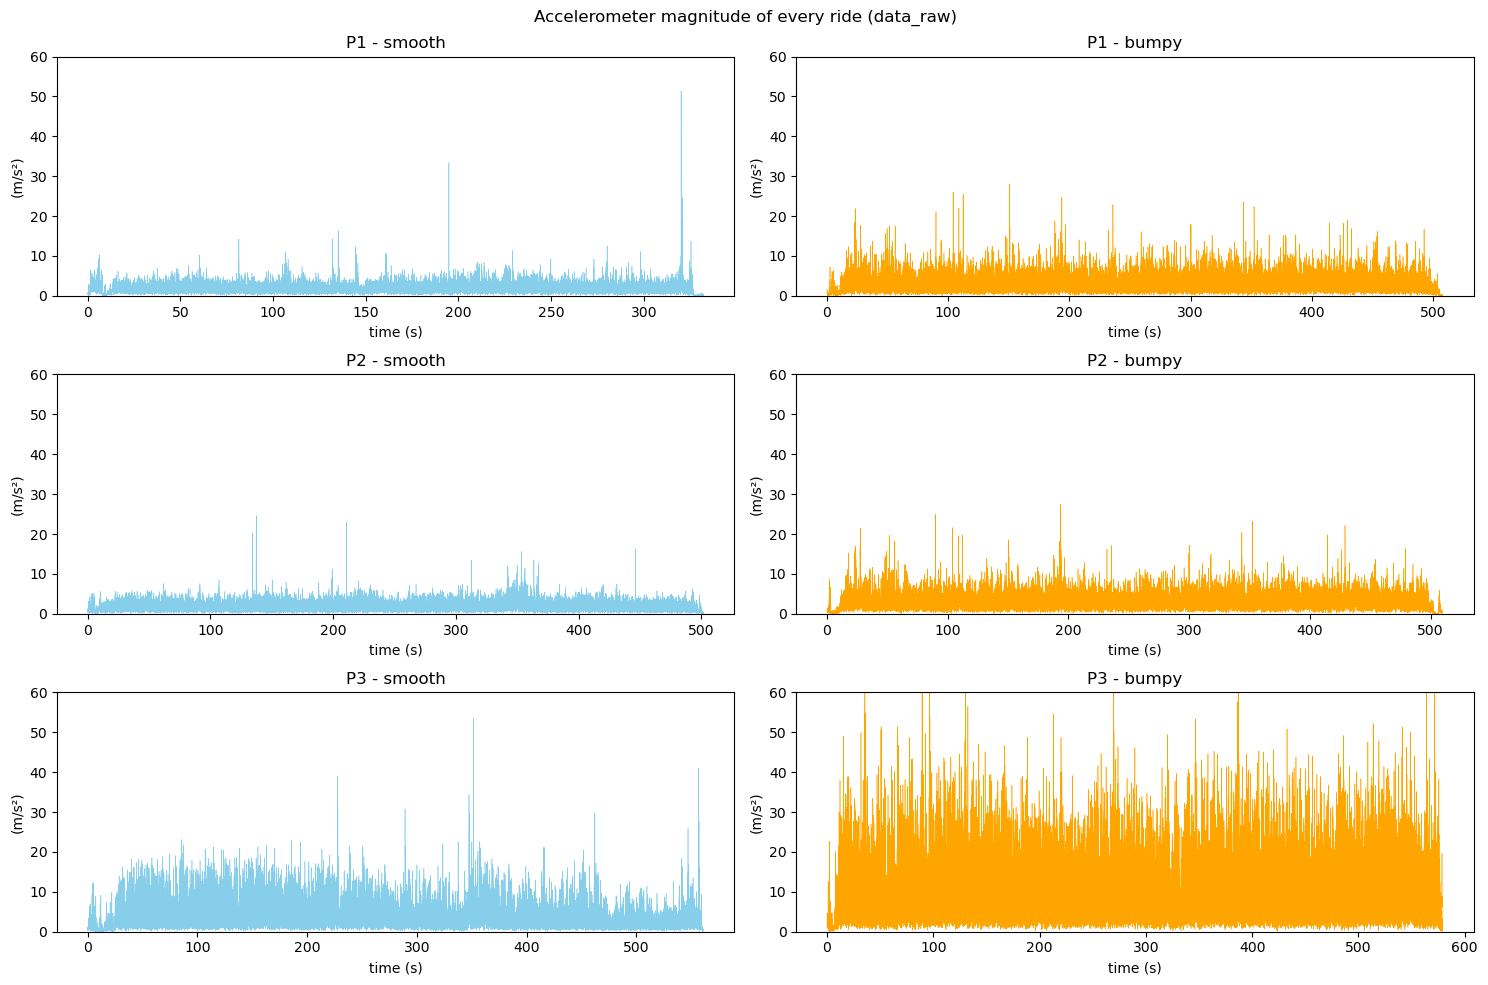

In [7]:
#Visualization of accelerometer magnitude of every ride

fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for i, participant in enumerate(['P1', 'P2', 'P3']):

    for j, label in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{participant}_{label}']
        magnitude = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

        if label == 'smooth':color = 'skyblue' 
        else:color = 'orange'
        
        axes[i,j].plot(df['seconds_elapsed'], magnitude, color, lw = 0.4)
        axes[i, j].set_title(f'{participant} - {label}')
        axes[i, j].set_ylim(0, 60)
        axes[i, j].set_ylabel('(m/s²)')
        axes[i, j].set_xlabel('time (s)')


plt.suptitle('Accelerometer magnitude of every ride (data_raw)')
plt.tight_layout()
plt.show()


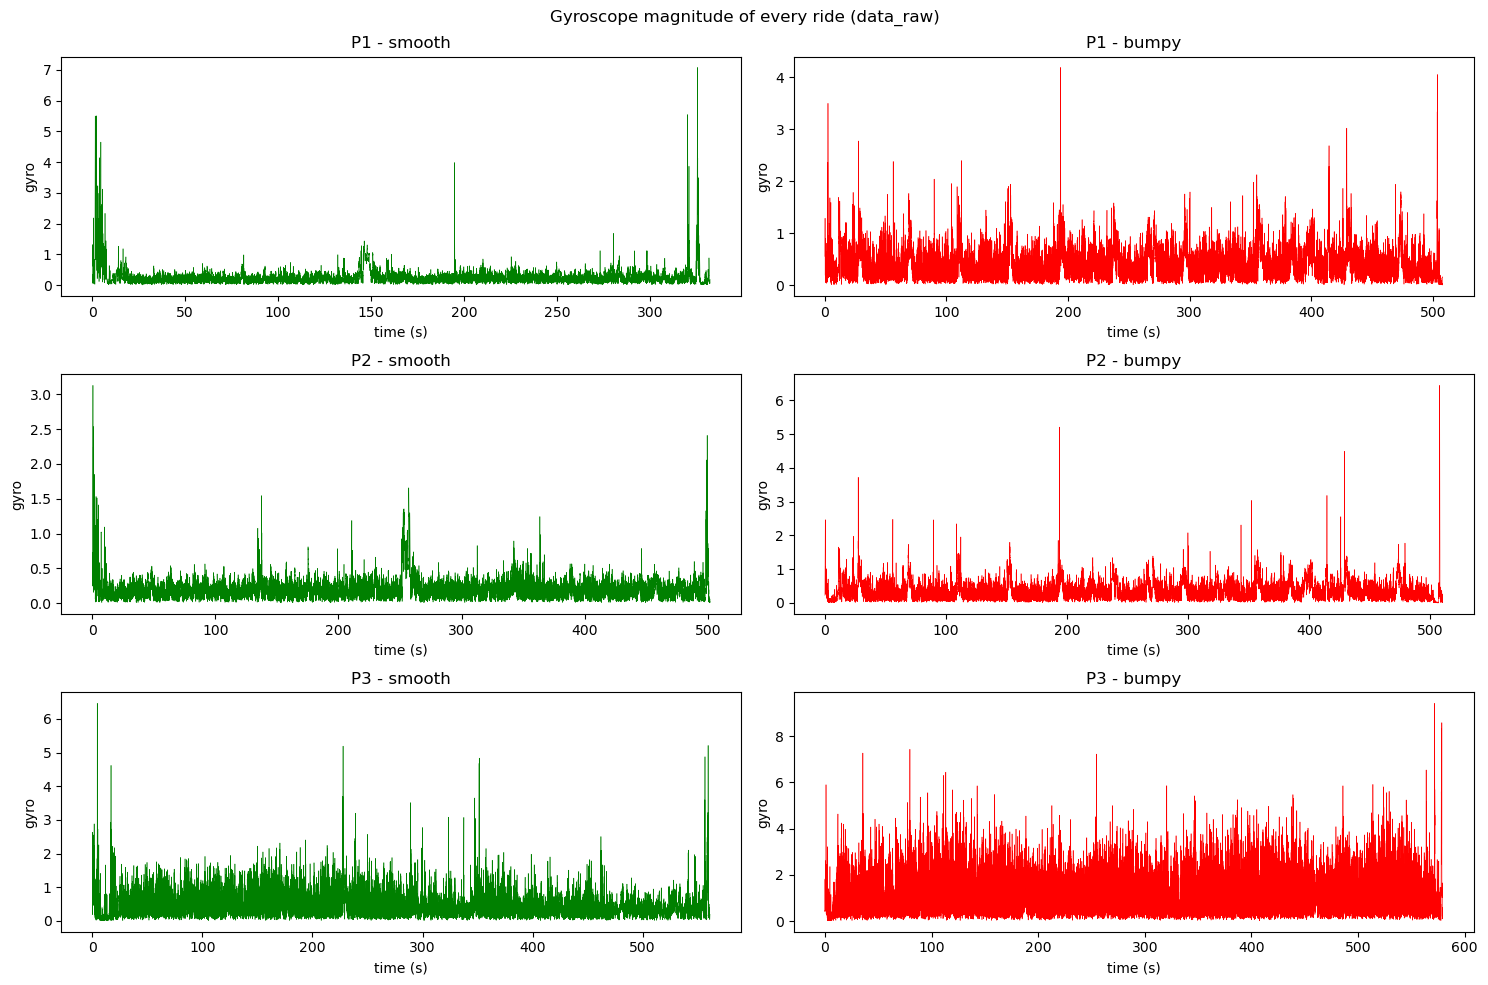

In [8]:
#Visualization of gyroscope magnitude of every ride

fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for i, participant in enumerate(['P1', 'P2', 'P3']):

    for j, label in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{participant}_{label}']
        magnitude = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

        if label == 'smooth':color = 'green' 
        else:color = 'red'
        
        axes[i,j].plot(df['seconds_elapsed'], magnitude, color, lw = 0.4)
        axes[i, j].set_title(f'{participant} - {label}')
        axes[i, j].set_ylabel('gyro')
        axes[i, j].set_xlabel('time (s)')


plt.suptitle('Gyroscope magnitude of every ride (data_raw)')
plt.tight_layout()
plt.show()

# Feature Engineering & Extraction

**Windowing strategy**

A single sensor reading do not reflect the road roughness. Roughness shows up as a pattern over a short time. So each ride is cut into windows, and each window becomes one example for the models.

- **Window length = 2 seconds = 200 readings** (100 readings per second × 2).
- **Step = 1 second = 100 readings.** The next window starts 1 second after the previous one, so windows get overlapped.

Overlap gives more examples and avoids cutting a bump in two. The side effect is that neighbouring windows are near-copies of each other, which might affect the testing model

In [9]:
Sampling_freq = 100
steps = 1
windows = 2

window_size = Sampling_freq * windows
step_size = Sampling_freq * steps

def create_window(df, window_size, step_size):
    windows_data = []

    for right in range (0, len(df)-window_size+1, step_size):
        left = right + window_size
        windows_data.append(df.iloc[right:left].copy())
    return windows_data

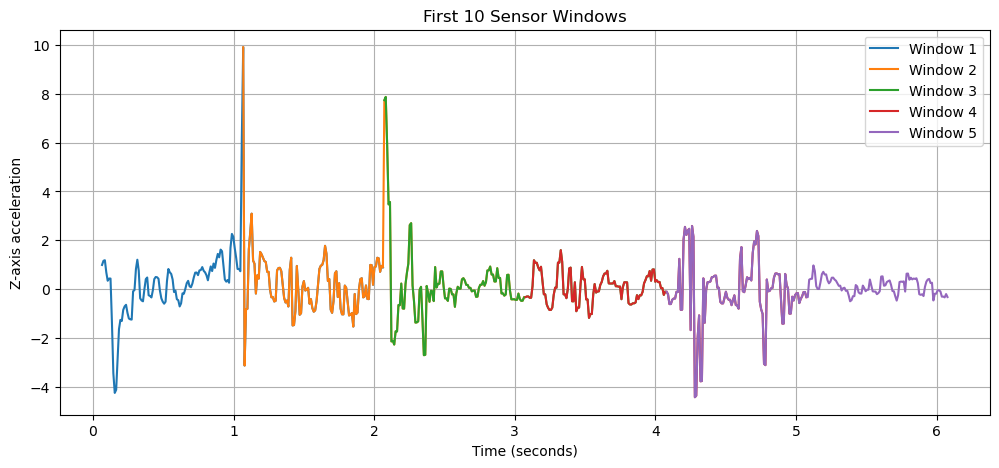

In [10]:
windows_data = create_window(df, window_size, step_size)

# Plot the first 10 windows
plt.figure(figsize=(12, 5))

for i, window in enumerate(windows_data[:5]):
    plt.plot(
        window["seconds_elapsed"],
        window["acc_x"],
        label=f"Window {i+1}"
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Z-axis acceleration")
plt.title("First 10 Sensor Windows")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
for name, df in merge_recordings.items():
    participant_windows = create_window(df, window_size, step_size)
    print(name," |rows-", len(df), " |duration-", round(df['seconds_elapsed'].iloc[-1],2), " |windows-",len(participant_windows))


P1_smooth  |rows- 33176  |duration- 332.21  |windows- 330
P1_bumpy  |rows- 50749  |duration- 508.12  |windows- 506
P2_smooth  |rows- 49779  |duration- 501.76  |windows- 496
P2_bumpy  |rows- 50613  |duration- 510.17  |windows- 505
P3_smooth  |rows- 55894  |duration- 561.1  |windows- 557
P3_bumpy  |rows- 57708  |duration- 579.33  |windows- 576


| Recording | Rows | Windows | Rider total |
|---|---:|---:|---:|
| P1_smooth | 33,176 | 330 | P1: 836 |
| P1_bumpy | 50,749 | 506 | |
| P2_smooth | 49,779 | 496 | P2: 1,001 |
| P2_bumpy | 50,613 | 505 | |
| P3_smooth | 55,894 | 557 | P3: 1,133 |
| P3_bumpy | 57,708 | 576 | |

- **Total: 2,970 windows** = 1,383 smooth (46.6 %) + 1,587 bumpy (53.4 %). Looks good for a balanced class, accuracy is fair.

**Feature Extraction**

Models cannot read a raw window of 200 readings. Each window is therefore summarised by features. For each of the three sensors, `extract_features()` first computes the magnitude of every reading in the window, then five statistics:

| Feature | In plain words | Why it helps |
|---|---|---|
| **std** | how much the signal wobbles | a shaky ride fluctuates more |
| **mean** | the certain level | rougher road, higher certain level |
| **rms** | an average that emphasises large values | reacts strongly to jolts |
| **min** | the lowest value | smoothness |
| **max** | the biggest single value | the strongest spike in the window |

3 sensors × 5 statistics = 15 features per window.

The next cell loops over all six rides, turns each into windows, works on the features, and adds three extra columns: `Window_id` , `participant` and `label`. The result is the table `feature_df`.

In [12]:
def extract_features(window):
    acc_magnitude = np.sqrt(window['acc_x']**2 + window['acc_y']**2 + window['acc_z']**2)
    grav_magnitude = np.sqrt(window['grav_x']**2+window['grav_y']**2+window['grav_z']**2)
    gyro_magnitude = np.sqrt(window['gyro_x']**2+window['gyro_y']**2+window['gyro_z']**2)

    features = {
        # Accelerometer
        'acc_std': acc_magnitude.std(),
        'acc_mean': acc_magnitude.mean(),
        'acc_rms': np.sqrt(np.mean(acc_magnitude**2)),
        'acc_min': acc_magnitude.min(),
        'acc_max': acc_magnitude.max(),

        # Gyroscope
        'gyro_std': gyro_magnitude.std(),
        'gyro_mean': gyro_magnitude.mean(),
        'gyro_rms': np.sqrt(np.mean(gyro_magnitude**2)),
        'gyro_min': gyro_magnitude.min(),
        'gyro_max': gyro_magnitude.max(),

        # Gravity
        'grav_std': grav_magnitude.std(),
        'grav_mean': grav_magnitude.mean(),
        'grav_rms': np.sqrt(np.mean(grav_magnitude**2)),
        'grav_min': grav_magnitude.min(),
        'grav_max': grav_magnitude.max()
    }

    return features

    

In [13]:
#Features dataframe showing mean, standard deviation, minimum, maximun and root mean square
feature_data = []

for header, df in merge_recordings.items():
    participant, label = header.split('_')
    participant_windows = create_window(df, window_size, step_size)
    
    for window_id, window in enumerate(participant_windows):
        feature = extract_features(window)
        feature['Window_id'] = window_id
        feature['participant'] = participant
        feature['label'] = label

        feature_data.append(feature)

feature_df = pd.DataFrame(feature_data)
print(feature_df.head())
print('\n',feature_df.shape)
print('\n', feature_df['label'].value_counts)


    acc_std  acc_mean   acc_rms   acc_min   acc_max  gyro_std  gyro_mean  \
0  1.463881  1.374221  2.005173  0.109140  6.402666  1.300457   1.083825   
1  1.525495  2.489323  2.917572  0.223551  6.402666  1.471055   1.978082   
2  1.292867  3.123863  3.379596  0.870259  6.498721  1.191529   1.916464   
3  1.339164  2.649562  2.967250  0.380867  6.498721  0.858917   1.341099   
4  1.624434  2.646282  3.102966  0.380867  9.235902  0.656756   1.135318   

   gyro_rms  gyro_min  gyro_max      grav_std  grav_mean  grav_rms  grav_min  \
0  1.690387  0.023482  5.498241  3.207383e-07    9.80665   9.80665  9.806649   
1  2.462923  0.023482  5.503100  5.327922e-07    9.80665   9.80665  9.806648   
2  2.255100  0.112729  5.503100  6.699135e-07    9.80665   9.80665  9.806648   
3  1.591413  0.112729  4.649344  6.732753e-07    9.80665   9.80665  9.806648   
4  1.310770  0.095997  4.649344  7.374127e-07    9.80665   9.80665  9.806648   

   grav_max  Window_id participant   label  
0  9.806651      

- `feature_df` has the shape (2,970, 18): 15 features + `Window_id`, `participant`, `label`.
- The first five rows (P1_smooth) show an accelerometer mean of about 1.4 to 3.1 and std of about 1.3 to 1.6.
- The gravity features are almost constant:The length of the gravity vector is always about 9.81 m/s². These five columns carry no necessary information about the road and are dropped in the feature-selection.

**Correlation between features**

- **X**: the table of inputs (the 15 feature columns).
- **y**: the answer to predict (the `label` column).

This computes the correlation between every pair of features. Correlation runs from −1 to 1:

- close to 1: when one feature goes up, the other goes up as well (they carry similar information)
- close to 0: no relation
- close to −1: when one goes up, the other goes down.

Highly correlated features are redundant also helps for feature selection. 

In [14]:
#Converting features into X and y variables to create a trainable dataset
X_feature_ext = ['acc_std','acc_mean','acc_rms','acc_min','acc_max',
                  'gyro_std','gyro_mean','gyro_rms','gyro_min','gyro_max',
                  'grav_std','grav_mean','grav_rms','grav_min','grav_max']

X_features = feature_df[X_feature_ext]
y_feature = feature_df['label']

print("X shape:", X_features.shape)
print("y shape:", y_feature.shape)


X shape: (2970, 15)
y shape: (2970,)


In [15]:
#Correlation between features
corr  = X_features.corr()
display(corr.round(2))

,acc_std,acc_mean,acc_rms,acc_min,acc_max,gyro_std,gyro_mean,gyro_rms,gyro_min,gyro_max,grav_std,grav_mean,grav_rms,grav_min,grav_max
acc_std,1.00,0.97,0.99,0.75,0.97,0.88,0.90,0.90,0.36,0.89,-0.43,0.40,0.40,0.46,-0.31
acc_mean,0.97,1.00,0.99,0.79,0.92,0.83,0.89,0.88,0.40,0.83,-0.41,0.37,0.37,0.45,-0.31
acc_rms,0.99,0.99,1.00,0.78,0.95,0.86,0.90,0.89,0.39,0.86,-0.42,0.39,0.39,0.46,-0.31
acc_min,0.75,0.79,0.78,1.00,0.71,0.64,0.72,0.70,0.34,0.64,-0.31,0.29,0.29,0.35,-0.23
acc_max,0.97,0.92,0.95,0.71,1.00,0.88,0.87,0.88,0.35,0.89,-0.41,0.40,0.40,0.45,-0.29
gyro_std,0.88,0.83,0.86,0.64,0.88,1.00,0.94,0.97,0.36,0.97,-0.43,0.40,0.40,0.44,-0.28
gyro_mean,0.90,0.89,0.90,0.72,0.87,0.94,1.00,0.99,0.55,0.92,-0.44,0.40,0.40,0.45,-0.31
gyro_rms,0.90,0.88,0.89,0.70,0.88,0.97,0.99,1.00,0.51,0.95,-0.44,0.41,0.41,0.45,-0.30
gyro_min,0.36,0.40,0.39,0.34,0.35,0.36,0.55,0.51,1.00,0.38,-0.19,0.17,0.17,0.18,-0.13
gyro_max,0.89,0.83,0.86,0.64,0.89,0.97,0.92,0.95,0.38,1.00,-0.43,0.40,0.40,0.45,-0.29


- **Features of the same sensor are almost the same information:** 
`acc_std`–`acc_rms` 0.99, `acc_mean`–`acc_rms` 0.99, `acc_std`–`acc_max` 0.97, `gyro_mean`–`gyro_rms` 0.99, `gyro_std`–`gyro_max` 0.97.
- **The two sensors move together:** accelerometer and gyroscope features correlate 0.83 to 0.90. When the bike shakes, both sensors react.
- The gravity features correlate only weakly with the accelerometer and gyroscope features (about −0.44 to 0.46). Since these columns are practically constant, those values reflect small differences and are not insightful.
- **Note:** there is a lot of repetition among the features. PCA should be used before every model to compresses it.

**Feature Selection**

Feature selection is the important process in the feature engineering.
As seen in the above output gravity features were not making any difference in dataset, their varaince was very low
We are choosing only the features which shows variance and correlation

The 10 remaining features are kept in the list `X_feature_selection`:

- accelerometer: `acc_std, acc_mean, acc_rms, acc_min, acc_max`
- gyroscope: `gyro_std, gyro_mean, gyro_rms, gyro_min, gyro_max`

From now on `X_features_selected` (the 10 features) and `y_feature_selected` (the label) are the inputs of every model. The next two cells show the correlation table and a heat map for these 10 features.

In [16]:
X_feature_selection = [
    'acc_std','acc_mean','acc_rms','acc_min','acc_max',
    'gyro_std','gyro_mean','gyro_rms','gyro_min','gyro_max'
]

X_features_selected = feature_df[X_feature_selection]
y_feature_selected = feature_df['label']

print("X shape:", X_features_selected.shape)
print("y shape:", y_feature_selected.shape)

X shape: (2970, 10)
y shape: (2970,)


In [17]:
#Correlation between features
corr  = X_features_selected.corr()
display(corr.round(2))

,acc_std,acc_mean,acc_rms,acc_min,acc_max,gyro_std,gyro_mean,gyro_rms,gyro_min,gyro_max
acc_std,1.00,0.97,0.99,0.75,0.97,0.88,0.90,0.90,0.36,0.89
acc_mean,0.97,1.00,0.99,0.79,0.92,0.83,0.89,0.88,0.40,0.83
acc_rms,0.99,0.99,1.00,0.78,0.95,0.86,0.90,0.89,0.39,0.86
acc_min,0.75,0.79,0.78,1.00,0.71,0.64,0.72,0.70,0.34,0.64
acc_max,0.97,0.92,0.95,0.71,1.00,0.88,0.87,0.88,0.35,0.89
gyro_std,0.88,0.83,0.86,0.64,0.88,1.00,0.94,0.97,0.36,0.97
gyro_mean,0.90,0.89,0.90,0.72,0.87,0.94,1.00,0.99,0.55,0.92
gyro_rms,0.90,0.88,0.89,0.70,0.88,0.97,0.99,1.00,0.51,0.95
gyro_min,0.36,0.40,0.39,0.34,0.35,0.36,0.55,0.51,1.00,0.38
gyro_max,0.89,0.83,0.86,0.64,0.89,0.97,0.92,0.95,0.38,1.00


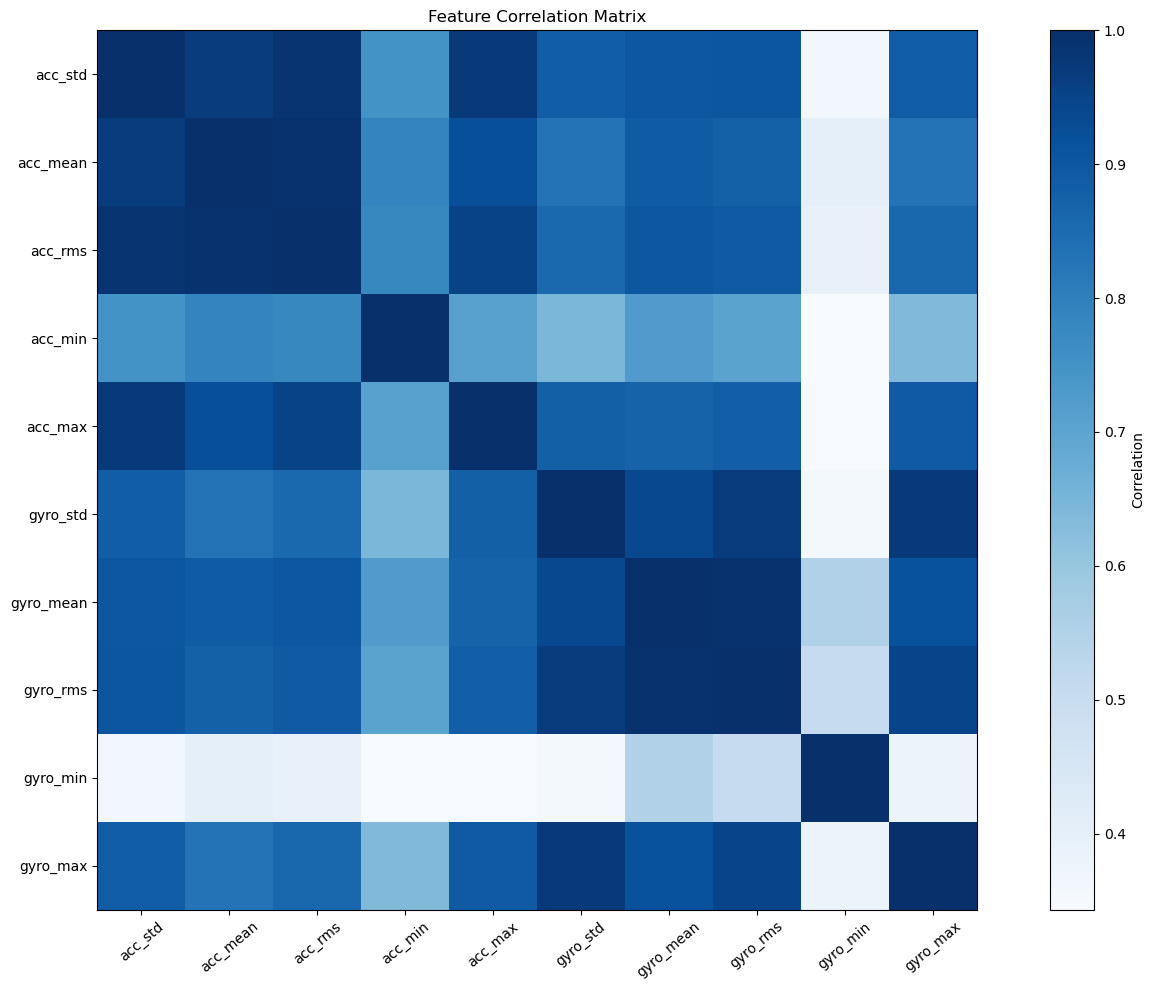

In [18]:
#Visualization of correlation 
plt.figure(figsize=(15, 10))

plt.imshow(corr, cmap='Blues')

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=40,
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label='Correlation')
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

- In the heat map, **darker blue means correlation closer to 1**. There is a large dark block formed by the accelerometer features and the gyroscope features.
- Keeping highly correlated features does no harm to the models used here, but because of this PCA is added before modelling.
- All 10 features respond to the same shaking, which explains the strong correlations.

**Mutual Information:** 
It measures how much knowing a feature reduces the uncertainty about the label. It is 0 when the feature says nothing about the class and gets larger as the feature becomes more informative. Unlike correlation, it also detects relationships that are not straight lines.

In [19]:
from sklearn.feature_selection import mutual_info_classif

y_num = y_feature_selected.map({
    'smooth':0,
    'bumpy':1
})

mi = mutual_info_classif(X_features_selected, y_feature_selected, random_state=42)

mi_df = pd.DataFrame({
    'Feature':X_features_selected.columns,
    'Mutual information': mi}
)

mi_df = mi_df.sort_values('Mutual information', ascending=False)

display(mi_df.round(2))

,Feature,Mutual information
4,acc_max,0.34
1,acc_mean,0.34
2,acc_rms,0.33
9,gyro_max,0.33
0,acc_std,0.31
5,gyro_std,0.25
3,acc_min,0.23
7,gyro_rms,0.23
6,gyro_mean,0.22
8,gyro_min,0.19


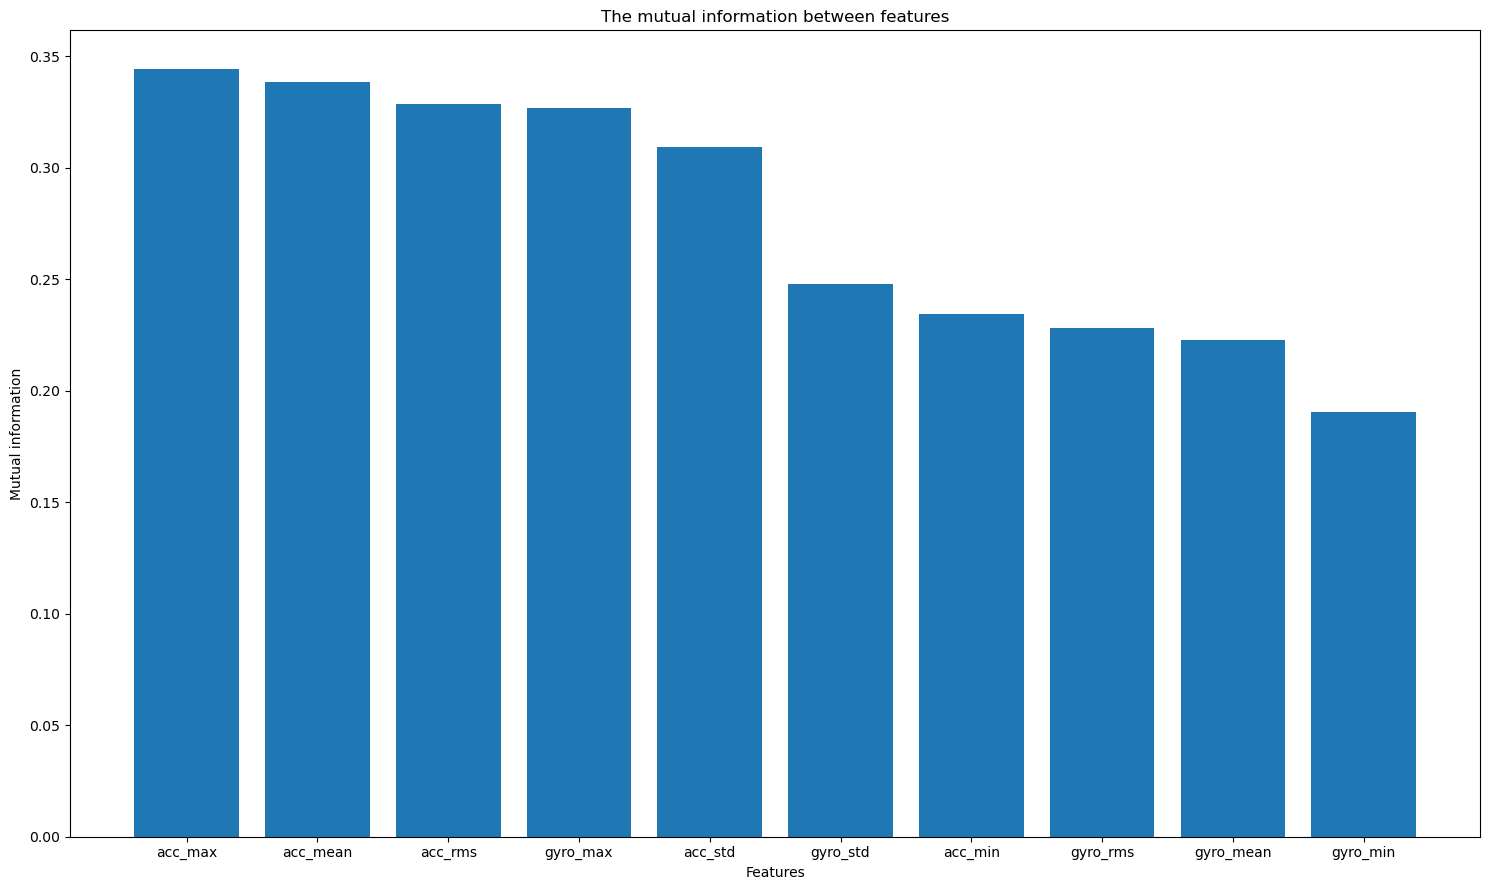

In [20]:
#Visualize the mutual information between features
plt.figure(figsize=(15,9))

plt.bar(mi_df['Feature'],mi_df['Mutual information'])

plt.xlabel('Features')
plt.ylabel('Mutual information')
plt.title('The mutual information between features')

plt.tight_layout()
plt.show()



- All 10 features have some information (none is close to 0), so keep them as it is.
- The accelerometer features are slightly more informative than the gyroscope features. The best features are the ones that react to strong shocks (`acc_max`, `acc_mean`, `acc_rms`, `gyro_max`).
- The largest value (0.34) is about half of the maximum possible for two balanced classes (about 0.69). No single feature differentiate between smooth and bumpy.

# Supervised Learning

**Supervised learning** means the model learns from examples that come with the right answer (the label), then predicts the answer.

All four models go through the same function, `build_supervised_model(model, model_name)`. Step by step:

1. **Split:** 75 % of the windows (2,227) are used for training, 25 % (743) are held back for testing (`test_size=0.25`). `random_state=42` makes the split identical every time.
2. **Scale (`StandardScaler`):** every feature is rewritten to average 0 and std 1. The scaler learns its averages from the training data and is then applied to the test data, so nothing from the test set leaks into training.
3. **PCA (keep 95 % of the information):** the correlated features are replaced by fewer, independent components.
4. **Train** the model on the training windows.
5. **Predict** the labels
6. **Confusion matrix:** a map of right and wrong answers.
7. **PCA scatter plot:** the training windows on the first two components (purple = bumpy, yellow = smooth).
8. **Scores:** accuracy, F1 and recall. F1 and recall are computed for the bumpy class.

**How to read a confusion matrix**:

| | Predicted bumpy | Predicted smooth |
|---|---|---|
| **Really bumpy** | found correctly | missed - called smooth |
| **Really smooth** | missed - called bumpy | found correctly |

In [21]:
def build_supervised_model(model, model_name):

        X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.25, random_state=42)
        #Scale the data 
        sc = StandardScaler()

        X_train_sc = sc.fit_transform(X_train)
        X_test_sc = sc.transform(X_test)

        #Apply PCA in training set
        pca = PCA(n_components=0.95) #varaince at 95%

        X_train_pca = pca.fit_transform(X_train_sc)
        X_test_pca = pca.transform(X_test_sc)

        #Model training 
        model.fit(X_train_pca, y_train)

        #Prediction on trained model
        y_pred = model.predict(X_test_pca)

        #Visulize the confusion matrix
        labels = ["bumpy", "smooth"]
        cm = confusion_matrix(y_test, y_pred, labels=labels)

        plt.figure(figsize=(6, 4))
        sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Greens",
                xticklabels=labels,
                yticklabels=labels
        )

        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")
        plt.title(f"Confusion Matrix - {model_name}")
        plt.tight_layout()
        plt.show()

        
        plt.figure(figsize=(8, 4))

        plt.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c = pd.Series(y_train).map({"bumpy": 0, "smooth": 1}),
        alpha=0.6
        )

        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")
        plt.title("Bike-Lane Data Visualized Using PCA")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        #Different types of validation of a model
        accuracy = accuracy_score(y_test, y_pred)
            
        f1_sc = f1_score(y_test, y_pred, pos_label='bumpy')
            
        re_sc = recall_score(y_test, y_pred, pos_label='bumpy')     

        df = pd.DataFrame({
        'accuracy':[accuracy],
        'f1_score':[f1_sc],
        'recall_score':[re_sc]
        })

        return df.round(2) 



1. Logistic Regression

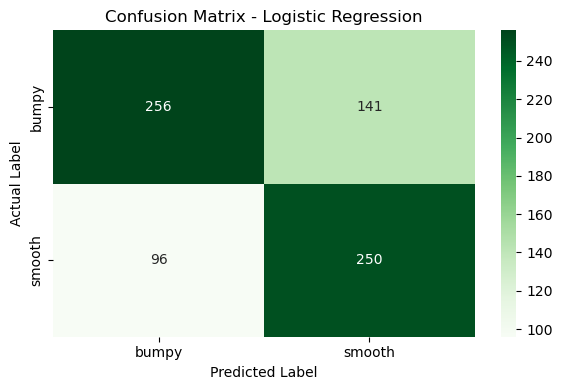

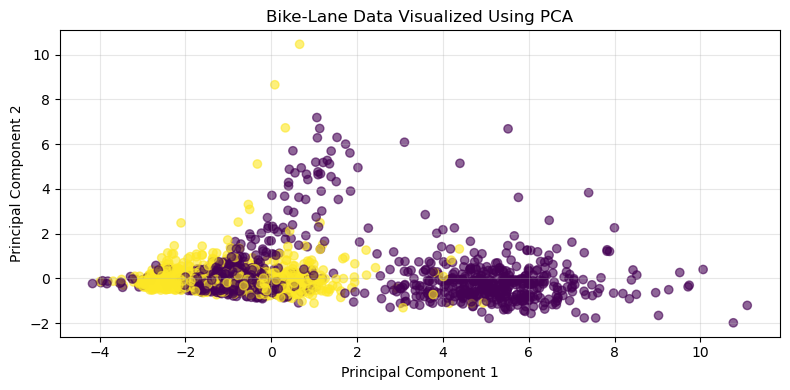

,accuracy,f1_score,recall_score
0,0.68,0.68,0.64


In [22]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_df = build_supervised_model(lr_model, "Logistic Regression")
display(lr_df)

2. k-Nearest Neighbors (k-NN)

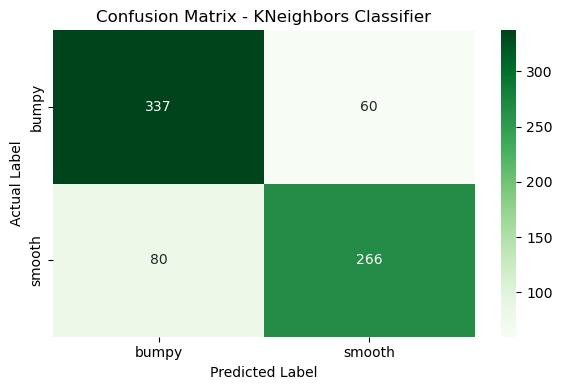

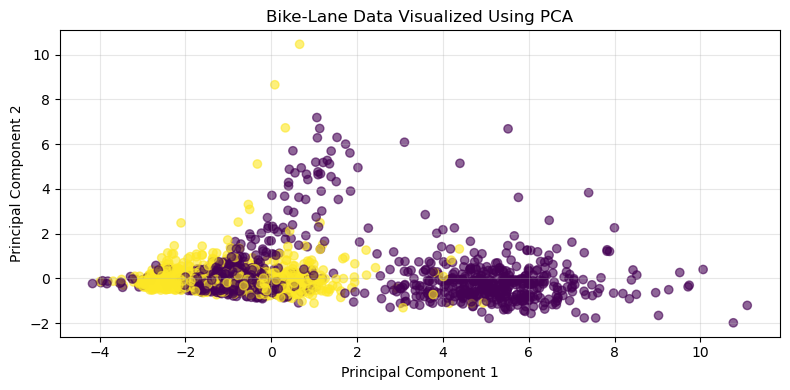

,accuracy,f1_score,recall_score
0,0.81,0.83,0.85


In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_df = build_supervised_model(knn_model, "KNeighbors Classifier")
display(knn_df)

3. Random Forest Classifier

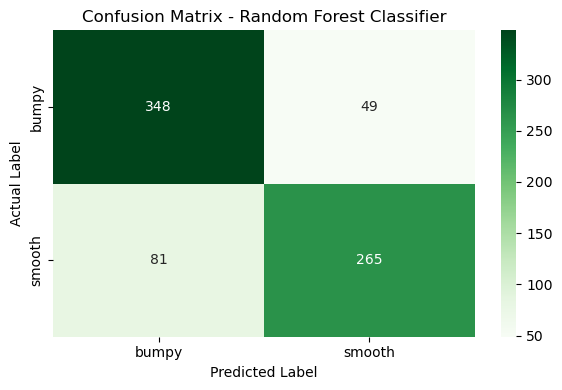

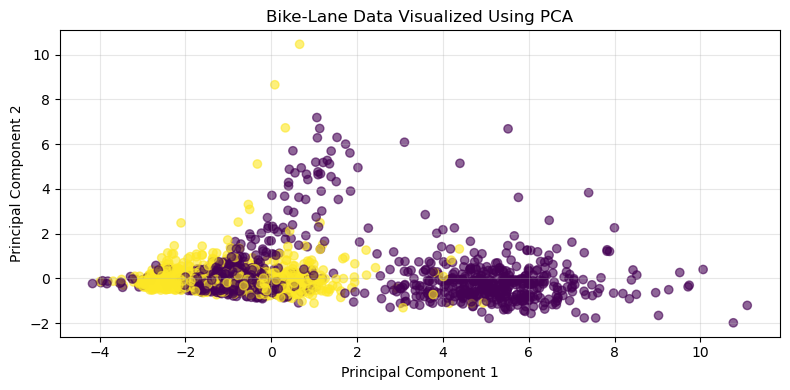

,accuracy,f1_score,recall_score
0,0.83,0.84,0.88


In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=50, criterion='entropy', max_depth=10, random_state=42)
rf_df = build_supervised_model(rf_model, "Random Forest Classifier")
display(rf_df)

4. Support Vector Classifier

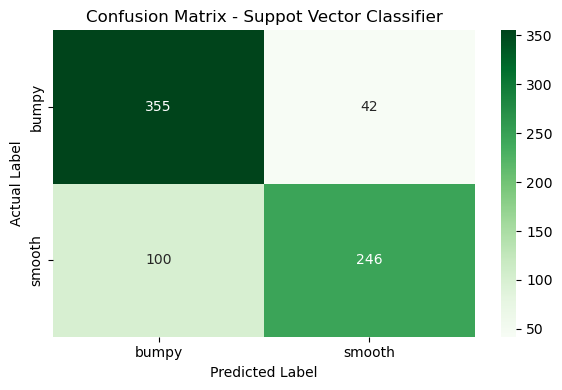

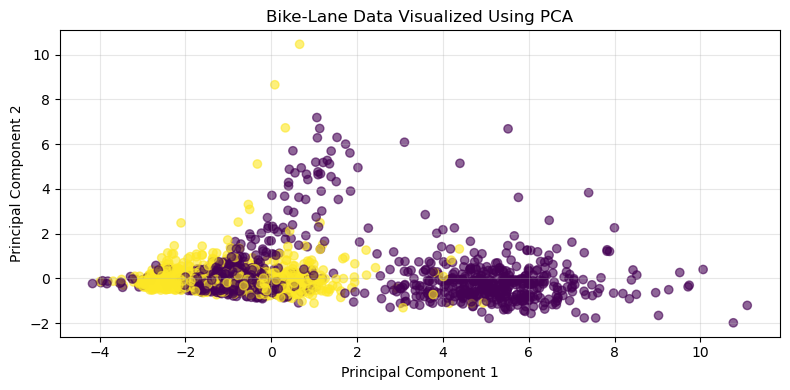

,accuracy,f1_score,recall_score
0,0.81,0.83,0.89


In [25]:
from sklearn.svm import SVC
svc_model = SVC(kernel='rbf')
svc_df = build_supervised_model(svc_model, 'Suppot Vector Classifier')
display(svc_df)

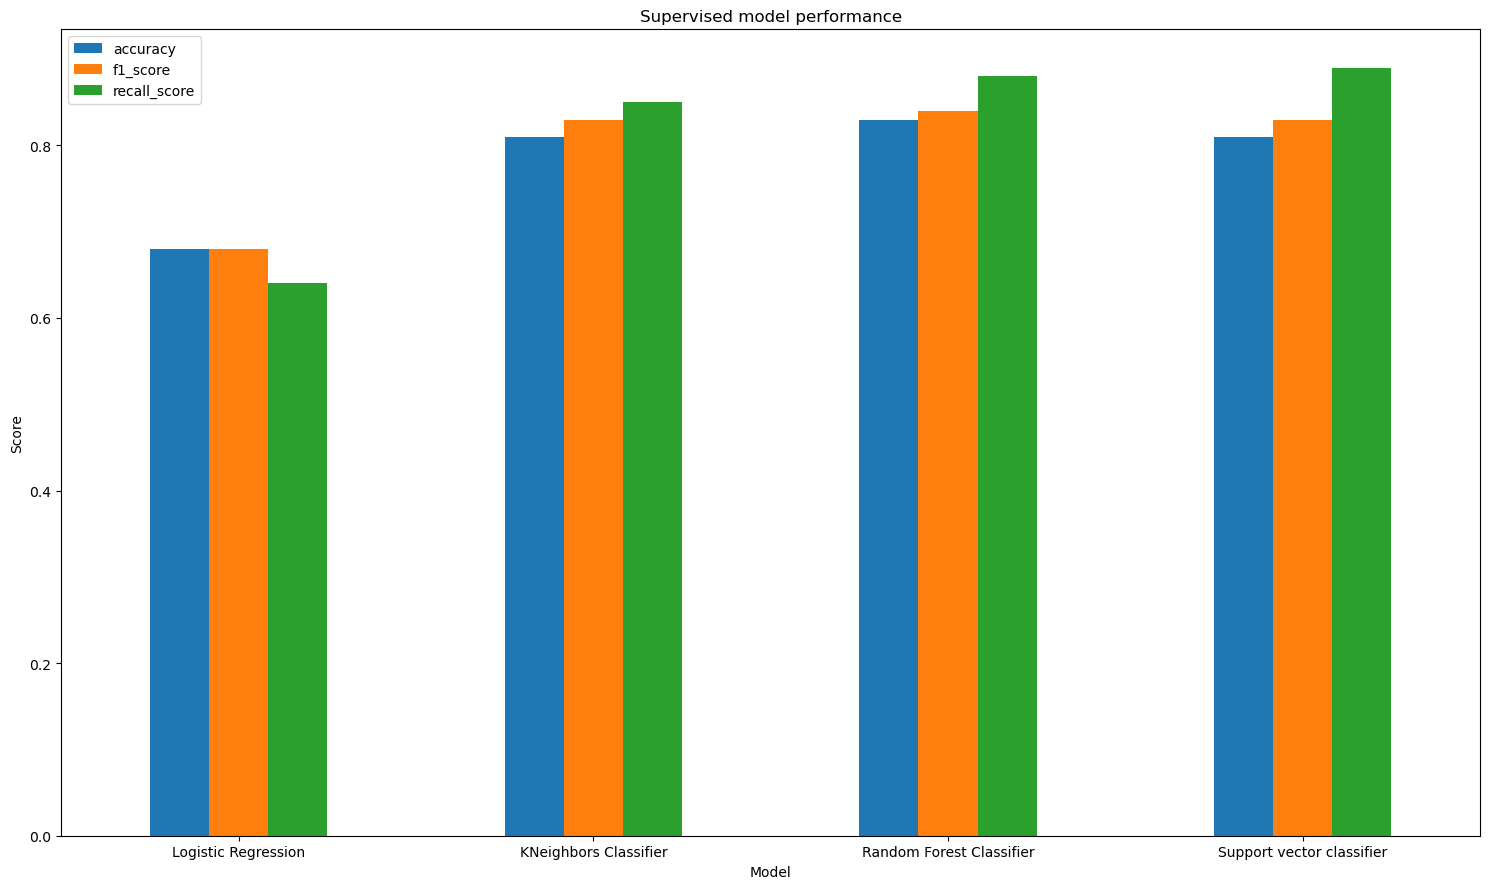

,accuracy,f1_score,recall_score
Logistic Regression,0.68,0.68,0.64
KNeighbors Classifier,0.81,0.83,0.85
Random Forest Classifier,0.83,0.84,0.88
Support vector classifier,0.81,0.83,0.89


In [26]:
#Visulaization of all models validation by mean
lr_mean = lr_df[['accuracy', 'f1_score', 'recall_score']].mean() 
knn_mean = knn_df[['accuracy', 'f1_score', 'recall_score']].mean() 
rf_mean = rf_df[['accuracy', 'f1_score', 'recall_score']].mean() 
svc_mean = svc_df[['accuracy', 'f1_score', 'recall_score']].mean() 

Total_mean = pd.DataFrame({
    'Logistic Regression':lr_mean,
    'KNeighbors Classifier':knn_mean,
    'Random Forest Classifier':rf_mean,
    'Support vector classifier':svc_mean
}).T #Transpose (models are rows and values are columns)

axes = Total_mean.plot(kind='bar', figsize=(15,9))

plt.title('Supervised model performance')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(Total_mean.round(2))


| Model | Accuracy | F1 (bumpy) | Recall (bumpy) | Bumpy missed | Smooth flagged as bumpy |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.68 | 0.68 | 0.64 | 141 | 96 |
| k-NN | 0.81 | 0.83 | 0.85 | 60 | 80 |
| Random Forest | 0.83 | 0.84 | 0.88 | 49 | 81 |
| SVC | 0.81 | 0.83 | 0.89 | 42 | 100 |

- **Logistic Regression is clearly the weakest.** The other three are within two percentage points of each other in accuracy (0.81 to 0.83).
- The models make different kinds of mistakes: SVC is the most cautious (best recall, most false alarms), while Random Forest and k-NN are more balanced. Which one is "best" depends on whether a missed bump or a false alarm is worse for the user.
- Random Forest is the model taken to deployment (best accuracy and F1, handles non-linear patterns, and repeatable thanks to `random_state=42`).

# Unsupervised Learning

**unsupervised learning:** The algorithm only sees the feature values and tries to find natural groups (clusters) by itself.

**Three scores are used.** Cluster numbers (0 and 1) are arbitrary names, so scores that do not depend on the numbering are used here instead of accuracy:

| Score | Needs labels? | Range | What it tells us |
|---|---|---|---|
| **Silhouette** | no | −1 to 1 | How tight and well separated the clusters are. Higher = clearer clusters. It says nothing about smooth/bumpy. |
| **ARI** | yes | about 0 to 1 | Agreement between the clusters and the true labels, corrected for chance. **0 ≈ random grouping, 1 = perfect match.** |
| **NMI** | yes | 0 to 1 | How much knowing the cluster tells you about the true label. 0 = nothing, 1 = everything. |


1. Agglomerative Clustering

A **bottom-up** method. It starts with every window as its own cluster and repeatedly merges the two closest clusters, until only 2 remain. The *ward* rule merges the pair that increases the within-cluster spread the least.

**Important limitation:** It can only cluster the exact windows it is given, so it cannot be fitted once and then applied to new data. In the notebook it is run directly on the test windows (`fit_predict`).

In [27]:
from sklearn.cluster import AgglomerativeClustering

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.25, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_scag = sc.fit_transform(X_train)
X_test_scag = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcaag = pca.fit_transform(X_train_scag)
X_test_pcaag = pca.transform(X_test_scag)

model_ac = AgglomerativeClustering(n_clusters=2, linkage='ward') #'ward' linkage minimizes the variance of merged clusters
clusters = model_ac.fit_predict(X_test_pcaag)

#Check if the true values are aligned with clusters
cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_ag = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_ag = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
ari_ag = adjusted_rand_score(y_test, clusters)
nmi_ag = normalized_mutual_info_score(y_test, clusters)
silhouette_ag = silhouette_score(X_test_pcaag, clusters)

agc_df = pd.DataFrame({
    "ARI": [ari_ag],
    "NMI": [nmi_ag],
    "Silhouette Score": [silhouette_ag]
    })

display(agc_df.round(4))    

,ARI,NMI,Silhouette Score
0,0.0845,0.1998,0.7039


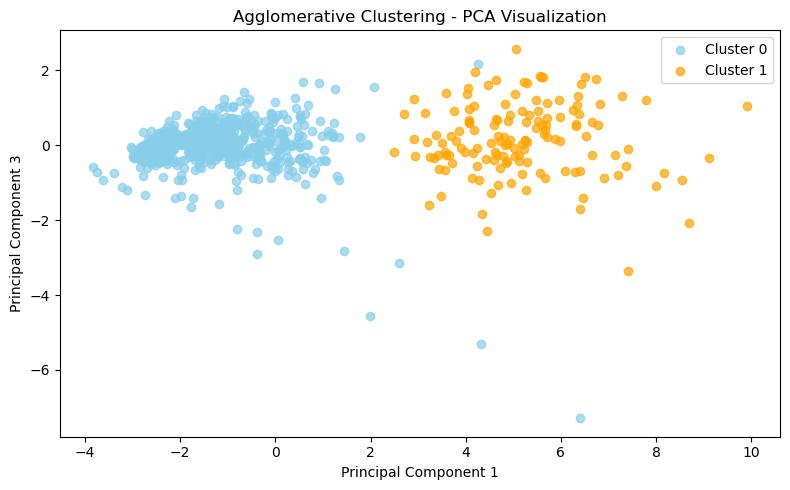

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_pcaag[clusters == 0, 0],
    X_test_pcaag[clusters == 0, 2],
    color="skyblue",
    label="Cluster 0",
    alpha=0.7
)

plt.scatter(
    X_test_pcaag[clusters == 1, 0],
    X_test_pcaag[clusters == 1, 2],
    color="orange",
    label="Cluster 1",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.title("Agglomerative Clustering - PCA Visualization")

plt.legend()
plt.tight_layout()
plt.show()

The clusters are compact and well separated (silhouette 0.71) but hardly related to smooth/bumpy (ARI 0.08, close to the "random" value 0; NMI 0.18).

2. K means Clustering

Picks 2 centre points, assigns every window to the nearest centre, moves each centre to the average of its windows, and repeats until nothing changes. It is fitted on the training windows and then **`predict()`** assigns the test windows to the nearest centre, so it can be applied to new data.

In [29]:
from sklearn.cluster import KMeans

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.25, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_sckm = sc.fit_transform(X_train)
X_test_sckm = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcakm = pca.fit_transform(X_train_sckm)
X_test_pcakm = pca.transform(X_test_sckm)

model_km = KMeans(n_clusters=2, random_state=42)
model_km.fit(X_train_pcakm)
clusters = model_km.predict(X_test_pcakm)

#Check if the true values are aligned with clusters
cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_km = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_km = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
ari_km = adjusted_rand_score(y_test, clusters)
nmi_km = normalized_mutual_info_score(y_test, clusters)
silhouette_km = silhouette_score(X_test_pcaag, clusters)

km_df = pd.DataFrame({
    "ARI": [ari_km],
    "NMI": [nmi_km],
    "Silhouette Score": [silhouette_km]
    })

display(km_df.round(4))    

c:\Users\Himanshu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Himanshu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Himanshu\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Himanshu\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

,ARI,NMI,Silhouette Score
0,0.0861,0.19,0.7098


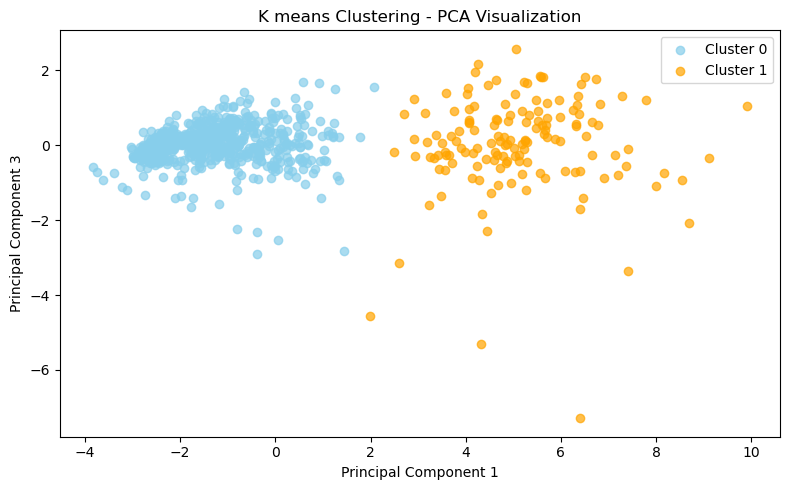

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_pcakm[clusters == 0, 0],
    X_test_pcakm[clusters == 0, 2],
    color="skyblue",
    label="Cluster 0",
    alpha=0.7
)

plt.scatter(
    X_test_pcakm[clusters == 1, 0],
    X_test_pcakm[clusters == 1, 2],
    color="orange",
    label="Cluster 1",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.title("K means Clustering - PCA Visualization")

plt.legend()
plt.tight_layout()
plt.show()

Almost identical to Agglomerative Clustering: the same large-left / small-right split.

3. Fuzzy C-Means Clustering

Every window belongs *partly* to both clusters (for example 70 % / 30 %). The fuzziness setting is `m=2`; the loop stops when the change is below `0.005` or after 1,000 iterations. The final cluster of a window is the one with the highest membership (`argmax`). It uses the **`scikit-fuzzy`** package (`cmeans` to fit, `cmeans_predict` for new data).

In [31]:
import skfuzzy as fuzz

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.25, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_scfc = sc.fit_transform(X_train)
X_test_scfc = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcafc = pca.fit_transform(X_train_scfc)
X_test_pcafc = pca.transform(X_test_scfc)

cntr, u_train,_,_,_,_,_ = fuzz.cluster.cmeans(X_train_pcafc.T,2,m=2, error=0.005, maxiter=1000)

u_test,_,_,_,_,_= fuzz._cluster.cmeans_predict(X_test_pcafc.T, cntr,2,error=0.005, maxiter=1000)

clusters = np.argmax(u_test, axis=0)

cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_fc = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_fc = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
ari_fc = adjusted_rand_score(y_test, clusters)
nmi_fc = normalized_mutual_info_score(y_test, clusters)
silhouette_fc = silhouette_score(X_test_pcaag, clusters)

fc_df = pd.DataFrame({
    "ARI": [ari_fc],
    "NMI": [nmi_fc],
    "Silhouette Score": [silhouette_fc]
    })

display(fc_df.round(4))  

,ARI,NMI,Silhouette Score
0,0.0877,0.1915,0.7099


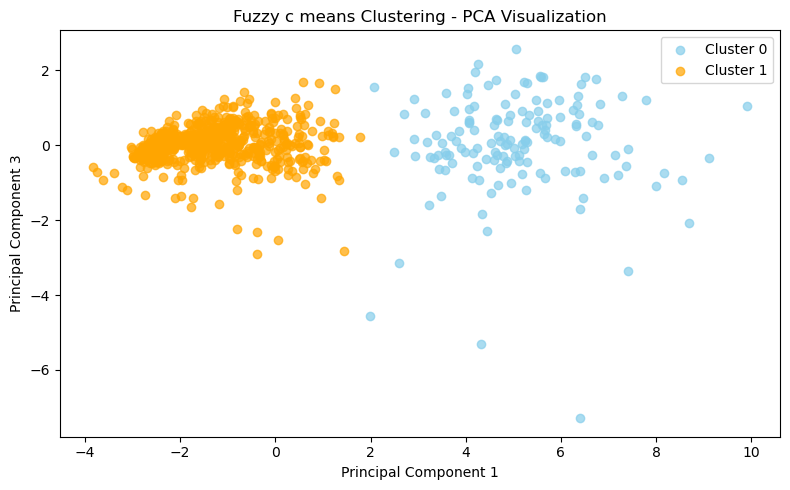

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_pcakm[clusters == 0, 0],
    X_test_pcakm[clusters == 0, 2],
    color="skyblue",
    label="Cluster 0",
    alpha=0.7
)

plt.scatter(
    X_test_pcakm[clusters == 1, 0],
    X_test_pcakm[clusters == 1, 2],
    color="orange",
    label="Cluster 1",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.title("Fuzzy c means Clustering - PCA Visualization")

plt.legend()
plt.tight_layout()
plt.show()

4. Gaussian Mixture Model

For every window it gives the probability of belonging to each cloud, and the more probable cloud is the cluster. It has both `predict()` and `predict_proba()`, so it can be applied to new data.

In [33]:
from sklearn.mixture import GaussianMixture

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.25, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_scgm = sc.fit_transform(X_train)
X_test_scgm = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcagm = pca.fit_transform(X_train_scgm)
X_test_pcagm = pca.transform(X_test_scgm)

model_gmm = GaussianMixture(n_components=2, random_state=42)
model_gmm.fit(X_train_pcagm)

clusters = model_gmm.predict(X_test_pcagm)

cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_gm = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_gm = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
ari_gm = adjusted_rand_score(y_test, clusters)
nmi_gm = normalized_mutual_info_score(y_test, clusters)
silhouette_gm = silhouette_score(X_test_pcaag, clusters)

gm_df = pd.DataFrame({
    "ARI": [ari_gm],
    "NMI": [nmi_gm],
    "Silhouette Score": [silhouette_gm]
    })

display(gm_df.round(4))  




c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


,ARI,NMI,Silhouette Score
0,0.088,0.1486,0.6572


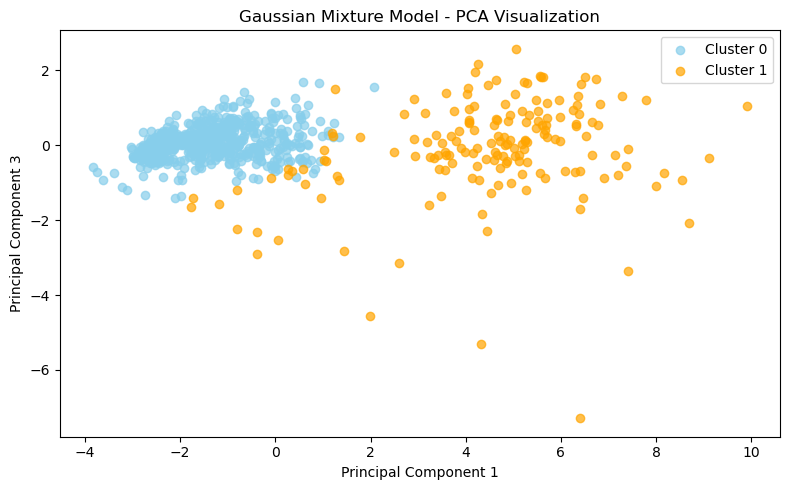

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_pcakm[clusters == 0, 0],
    X_test_pcakm[clusters == 0, 2],
    color="skyblue",
    label="Cluster 0",
    alpha=0.7
)

plt.scatter(
    X_test_pcakm[clusters == 1, 0],
    X_test_pcakm[clusters == 1, 2],
    color="orange",
    label="Cluster 1",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.title("Gaussian Mixture Model - PCA Visualization")

plt.legend()
plt.tight_layout()
plt.show()

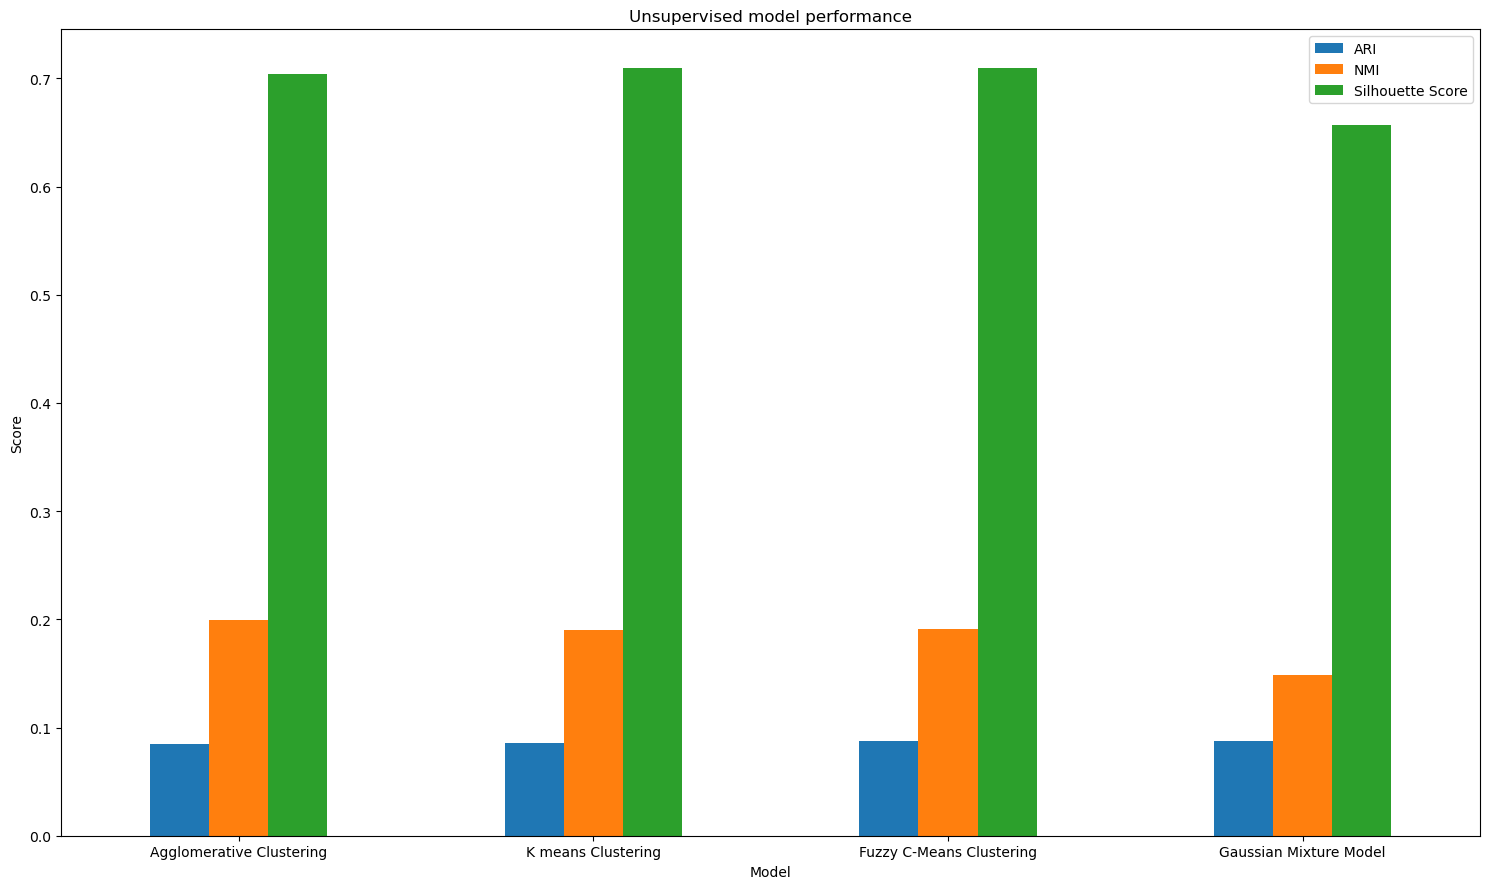

,ARI,NMI,Silhouette Score
Agglomerative Clustering,0.0845,0.1998,0.7039
K means Clustering,0.0861,0.1900,0.7098
Fuzzy C-Means Clustering,0.0877,0.1915,0.7099
Gaussian Mixture Model,0.0880,0.1486,0.6572


In [35]:
agc = agc_df[['ARI', 'NMI', 'Silhouette Score']].iloc[0]
km = km_df[['ARI', 'NMI', 'Silhouette Score']].iloc[0]
fc = fc_df[['ARI', 'NMI', 'Silhouette Score']].iloc[0]
gm = gm_df[['ARI', 'NMI', 'Silhouette Score']].iloc[0]

Total_ = pd.DataFrame({
    'Agglomerative Clustering':agc,
    'K means Clustering':km,
    'Fuzzy C-Means Clustering':fc,
    'Gaussian Mixture Model':gm
}).T #Transpose (models are rows and values are columns)

axes = Total_.plot(kind='bar', figsize=(15,9))

plt.title('Unsupervised model performance')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(Total_.round(4))

| Method | ARI | NMI | Silhouette |
|---|---:|---:|---:|
| Agglomerative | 0.0782 | 0.1787 | 0.7125 |
| K-Means | 0.0808 | 0.1853 | 0.7138 |
| Fuzzy C-Means | 0.0821 | 0.1866 | 0.7140 |
| GMM | 0.0785 | 0.1370 | 0.6564 |

- All four methods give practically the same result The differences (for example ARI 0.0782 vs 0.0821) are tiny and not meaningful, so none can be called the best.
- Silhouette is high (about 0.7) but ARI is close to zero (about 0.08) and NMI is low (0.14 to 0.19). The methods found a clear structure in the data, but it is not the smooth/bumpy structure.
- For comparison, three of the supervised models reach about 0.81 to 0.83 accuracy on held-out windows (Logistic Regression 0.68), using a slightly different split. The scores are not on the same scale, but the contrast is clear: with the labels the models can separate the classes; without them, these methods find a different grouping.

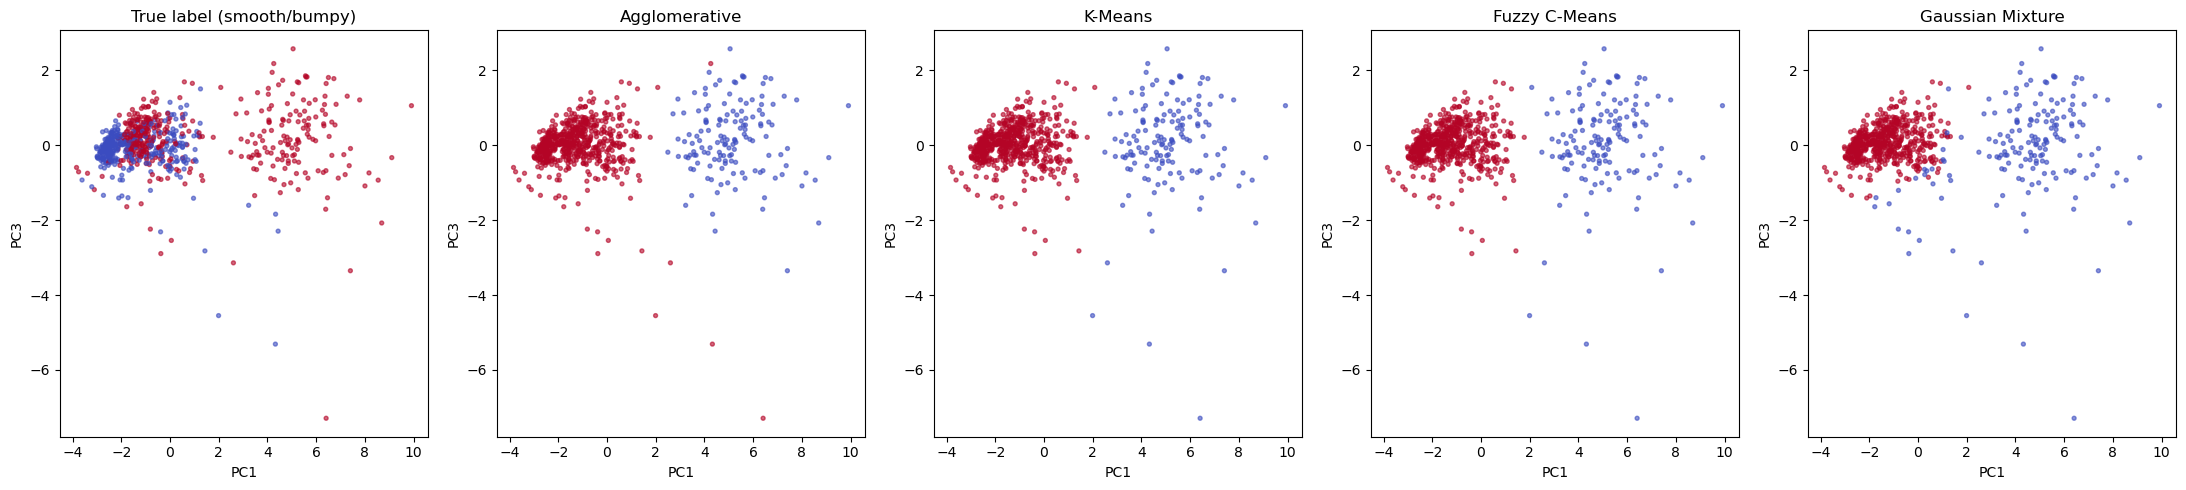

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Convert the true string labels to 0 (smooth) and 1 (bumpy) for coloring
y_true_num = [1 if label == 'bumpy' else 0 for label in y_test]

results = [
    ('Agglomerative', [1 if p == 'bumpy' else 0 for p in y_pred_ag]),
    ('K-Means', [1 if p == 'bumpy' else 0 for p in y_pred_km]),
    ('Fuzzy C-Means', [1 if p == 'bumpy' else 0 for p in y_pred_fc]),
    ('Gaussian Mixture', [1 if p == 'bumpy' else 0 for p in y_pred_gm])
]

# 3. Select your PCA data (since the splits and PCA settings were identical, any of your test PCAs will work)
X_pca = X_test_pcakm 

# 4. Your plotting code (updated for consistent colors)
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

# Plot True Labels
axes[0].scatter(X_pca[:, 0], X_pca[:, 2], c=y_true_num, cmap='coolwarm', s=8, alpha=0.6)
axes[0].set_title('True label (smooth/bumpy)')

# Plot Predicted Labels
for ax, (name, labels) in zip(axes[1:], results):
    # Changed cmap to 'coolwarm' so the colors match the True Label chart exactly
    ax.scatter(X_pca[:, 0], X_pca[:, 2], c=labels, cmap='coolwarm', s=8, alpha=0.6)
    ax.set_title(name)

# Apply axes labels
for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC3')

plt.tight_layout()
plt.show()

# Deployment

**Deployment** means using the finished model on completely new data: here an *external* ride that was never used for training or testing. The cell does the following:

1. `extract_window_features()` / `extract_recording_features()` build the same kind of features as before (std, mean, rms, min, max of the three magnitudes) for every window of a ride.
2. Load the external ride from `data/external_data/` with the same `load_and_merge()` and cut it into windows with the same settings (2 s windows, 1 s step).
3. Keep the same 10 columns, in the same order, that the scaler saw during training (`sc.feature_names_in_`).
4. Apply the already-fitted `sc` (scaler) and `pca`** with `.transform()`.
5. **Random Forest** has the overall best performance in all supervised and unsupervised models. 
8. **Timeline plot:** the x-axis is the time at the middle of each window. The background is **green where the bumpy probability is below 0.5 (smooth) and red where it is 0.5 or more (bumpy)**; the black line is the probability itself.

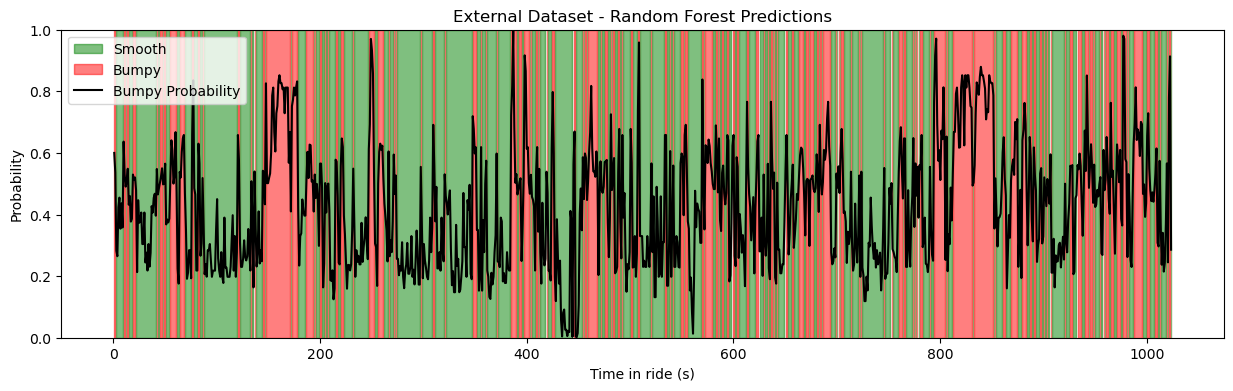

Prediction counts:


,Count
Predicted_Class,
smooth,638
bumpy,380


In [37]:
def extract_window_features(window):
    """Extract statistical features from one sensor window."""

    features = {}

    for sensor in ["acc", "gyro", "grav"]:
        magnitude = np.sqrt(
            window[f"{sensor}_x"]**2
            + window[f"{sensor}_y"]**2
            + window[f"{sensor}_z"]**2
        )

        values = magnitude.to_numpy()

        features[f"{sensor}_std"] = np.std(values)
        features[f"{sensor}_mean"] = np.mean(values)
        features[f"{sensor}_rms"] = np.sqrt(np.mean(values**2))
        features[f"{sensor}_min"] = np.min(values)
        features[f"{sensor}_max"] = np.max(values)

    return features


def extract_recording_features(df, window_size, step_size):
    """Create windows and extract features from each window."""

    windows_data = create_window(df, window_size, step_size)

    features = [
        extract_window_features(window)
        for window in windows_data
    ]

    return pd.DataFrame(features)



# Load external sensor recording
df_external = load_and_merge(
    "data/external_data/Accelerometer.csv",
    "data/external_data/Gravity.csv",
    "data/external_data/Gyroscope.csv"
)

# Use the same window settings as training
Sampling_freq = 100
windows = 2
steps = 1

window_size = Sampling_freq * windows
step_size = Sampling_freq * steps

# Extract features from all windows
X_external = extract_recording_features(
    df_external, window_size, step_size
)

# Match the feature order used during training
if hasattr(sc, "feature_names_in_"):
    X_external = X_external[list(sc.feature_names_in_)]

# Apply the previously fitted preprocessing steps
X_external_scaled = sc.transform(X_external)
X_external_pca = pca.transform(X_external_scaled)

predictions = rf_model.predict(X_external_pca)

# Probability that each window is bumpy
bumpy_prob = rf_model.predict_proba(X_external_pca)[:, 0]

# Time at the middle of each window
window_cal = df_external["seconds_elapsed"].iloc[window_size // 2 : len(df_external) - window_size // 2 : step_size].values[:len(bumpy_prob)]

# Plot
plt.figure(figsize=(15, 4))

plt.fill_between(window_cal, 0, 1, where= bumpy_prob < 0.5,color="green", alpha=0.5, label="Smooth")

plt.fill_between(window_cal, 0, 1, where=bumpy_prob >= 0.5,color="red", alpha=0.5, label="Bumpy")

plt.plot(window_cal,bumpy_prob, color="black", label="Bumpy Probability")

plt.xlabel("Time in ride (s)")
plt.ylabel("Probability")
plt.title("External Dataset - Random Forest Predictions")
plt.ylim(0, 1)
plt.legend()
plt.show()

# Display predictions for each window
results = pd.DataFrame({
    "Window": np.arange(1, len(predictions) + 1),
    "Predicted_Class": predictions
})

print("Prediction counts:")
display(results["Predicted_Class"].value_counts().to_frame("Count"))

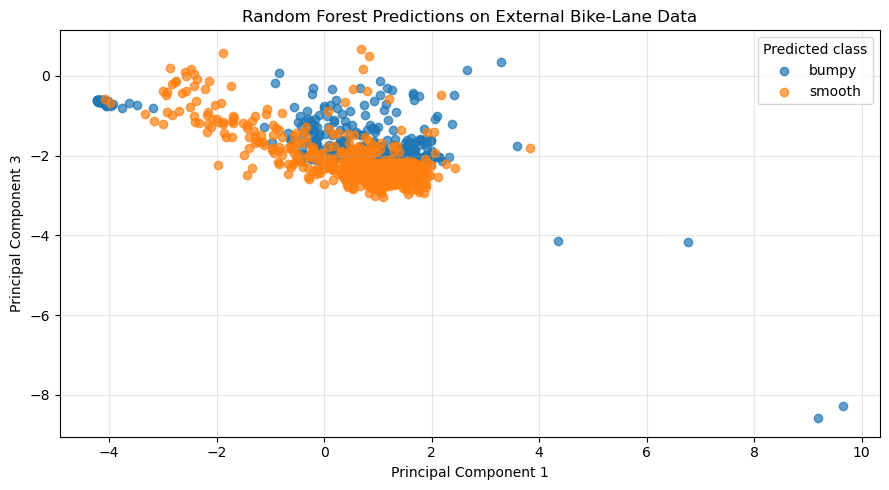

In [38]:
if X_external_pca.shape[1] >= 2:
    plt.figure(figsize=(9, 5))

    for label in pd.unique(predictions):
        mask = predictions == label

        plt.scatter(
            X_external_pca[mask, 0],
            X_external_pca[mask, 2],
            label=str(label),
            alpha=0.7
        )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 3")
    plt.title("Random Forest Predictions on External Bike-Lane Data")
    plt.legend(title="Predicted class")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("At least two PCA components are required for this plot.")

| Predicted class | Windows | Share |
|---|---:|---:|
| smooth | 638 | 62.7 % |
| bumpy | 380 | 37.3 % |
| Total | 1,018 | 100 % |

- 1,018 windows correspond to a ride of roughly **17 minutes**.
- On the timeline, the bumpy probability mostly **hovers between about 0.2 and 0.6**, so many windows are uncertain, and the prediction **flips quickly** between smooth and bumpy from one window to the next. There are also some clear sustained bumpy stretches (for example around 140 to 180 s and 800 to 850 s) and a very calm stretch around 430 to 450 s where the probability falls to about 0.
- **There is no ground truth for the external ride**, so no accuracy can be computed. The 0.83 accuracy measured earlier came from windows of rides the model had already seen; how well it works on a new rider is not known. The result can only be sanity-checked, for example against what is known about the route.
- A possible refinement (not done here): smooth the predictions over a few neighbouring windows to reduce the rapid flipping.